In [1]:
#%% AUC DO sprawdzenia, powinno byc 0,86/0,87
import mne
import numpy as np
import pandas as pd
import warnings
from tqdm import tqdm
from sklearn import metrics as sklearn_metrics
import json
import multiprocessing

import h5pickle
import numpy as np
import os
import glob

import torchdata
from torchdata.dataloader2 import DataLoader2, MultiProcessingReadingService
from tqdm import tqdm
import torch

import json
import multiprocessing

import h5pickle
import numpy as np
import toml
import os
import glob

import torchdata
from torchdata.dataloader2 import DataLoader2, MultiProcessingReadingService
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc, silhouette_score, davies_bouldin_score, matthews_corrcoef, accuracy_score, roc_auc_score
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
from sklearn import metrics as sklearn_metrics

import random
import h5py

import torch
import torchdata

import json
import multiprocessing
import torch.nn as nn
import torch.autograd as autograd
from tqdm import tqdm

import h5pickle
import toml
import os
import glob

import torchdata.datapipes as dp
from torch.autograd import Function
# Używamy standardowego DataLoadera, który jest stabilny
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from loader_utils import label_override, load_label_override, load_metadata_database, stratified_sample, read_folds_override, get_eids_for_folds, stratified_sample


from loader_utils import label_override, load_label_override, load_metadata_database, stratified_sample, read_folds_override, get_eids_for_folds, stratified_sample

data_pth = "/dmj/fizmed/mpoziomska/ELMIKO/neuroscreening-fuw/data/elmiko/processed_all_MIL_800"
model_pth = "/dmj/fizmed/jpelczar/od_martyny/minet/models/minet_raw_fold_6"
#%%
def collate_pad(batch):
    X, y, eid = zip(*batch)
    y = torch.tensor(y)
    X = torch.nn.utils.rnn.pad_sequence(X, batch_first=True)
    return [X, y, eid]

def collate_pad_exp(batch):
    X, y, eid, desc, key = zip(*batch)
    y = torch.tensor(y)
    X = torch.nn.utils.rnn.pad_sequence(X, batch_first=True)
    return [X, y, eid, desc, key]


class Loader:

    def __init__(self, data_path, eids, label_override='classification_latest',
                 override_non_mil=False,
                 minet_subsampling_n=None,
                 num_workers=None):
        """
        params:
        override_non_mil - unbatches whole cut signals into seperate cuts as examples
        minet_subsample_n - if a signal has more fragments than given number, the fragments will be randomly subsampled
        """
        self._num_workers = num_workers
        self.minet_subsampling_n = minet_subsampling_n
        
        # h5pickle allows for Dataloader2 to use h5 file for READING ONLY from multiple processes
        self._data_file = h5pickle.File(os.path.join(data_path, 'features', 'data.hdf5'), 'r')

        self.labels_database = load_label_override(label_override, data_path)
        self.metadata_database = load_metadata_database(data_path)

        # will be loaded during mil
        # we want this metadata dict to be populated by all the reader processes
        manager = multiprocessing.Manager()
        self.additional_metadata = manager.dict()
        # it will not have padded event types...

        # caching the metadata from h5 file to increase access speed, maybe allow metadata altering later?
        # seems that metadata caching causes memory leak...
        # self.additional_metadata = self.load_metadata()

        if override_non_mil:
            self._loader_type = 'none'
        else:
            self._loader_type = 'MIL'

        self._data_path = data_path
        self._eids = eids
        

    def construct_data_pipe(self, batch_size, pad):
        pipe = torchdata.datapipes.map.SequenceWrapper(self._eids)
        pipe = pipe.shuffle()
        pipe = pipe.sharding_filter()
        pipe = pipe.map(self.loader_mapping_func)

        if self._loader_type == "none":
            pipe = pipe.unbatch()
            # pipe = pipe.shuffle(buffer_size=10000) ten if jest tylko dla EEGNet. Jeżeli model nie będzie uczony to szuflowanie nie jest potrzebne, ale do nauki lepiej to odkomentować.

        pipe = pipe.batch(batch_size=batch_size, drop_last=False)

        if (self._loader_type == 'MIL') and pad:
            pipe = pipe.collate(collate_pad)
        else:
            pipe = pipe.collate()
        return pipe

    def load_metadata(self):
        eids = self._data_file['metadata'].attrs.keys()
        metadata = {}
        for eid in tqdm(eids, desc="loading additional metadata"):
            additional_metadata = json.loads(self._data_file['metadata'].attrs[eid])
            metadata[eid] = additional_metadata
        return metadata


    def loader_mapping_func(self, eid):
        cls = 1 - label_override([eid], self.labels_database)[0] # w tabelce norma to 0 a patologia to 1, ale modele trenowaliśmy z odwrotnymi labelkami
        additional_metadata = json.loads(self._data_file['metadata'].attrs[eid])

        cls_torch = torch.tensor(int(cls), dtype=torch.int64)
        data_h5 = np.array(self._data_file['features']['{}'.format(eid)])
        frames_n = data_h5.shape[0]

        frame_types = additional_metadata.get('events_list', ["None"] * frames_n)
        frame_timings = additional_metadata.get('event_timewindows', [[0, 0]] * frames_n)

        if self.minet_subsampling_n is not None and frames_n > self.minet_subsampling_n:
            # additional_metadata = self.additional_metadata[eid]
            data_h5, frame_types, frame_timings = stratified_sample(self.minet_subsampling_n, data_h5,
                                                                    frame_timings, frame_types)
        data = torch.tensor(data_h5)
        additional_metadata['events_list'] = frame_types
        additional_metadata['event_timewindows'] = frame_timings
        self.additional_metadata[eid] = additional_metadata
        if self._loader_type == "none":
            # pretend that this is a batch
            outlist = []
            for i in range(len(data)):
                data_ = data[i]
                outlist.append((data_, cls_torch, eid))
            return outlist
        else:
            return (data,
                    cls_torch,
                    eid
                    )
    
    def get_batched_loader(self, batch_size, pad=True):
        # padding is needed for MIL training and evaluation
        # preprocessing histograms  doesn't need it, as it doesn't use the data, and it breaks due dataset
        # returning more than 3 values

        pipe = self.construct_data_pipe(batch_size, pad)

        # with 100000 examples in the buffor of a shape 19x600 of float32 we need 24 gigabytes of ram for 4 reading threads, because EACH thread has a buffer.
        # normally 100000 examples of shape 19x16 should fit in 4-5 gigabytes, depending on python overhead
        # but useag easily goes over
        # buffer of 10k might still make sense
        if self._num_workers is not None:
            num_workers = self._num_workers
        else:
            num_workers = min([6, multiprocessing.cpu_count() - 1])
        mp_rs = MultiProcessingReadingService(num_workers=num_workers)
        return DataLoader2(pipe, reading_service=mp_rs)
        # return DataLoader2(pipe)

#%%
dtype = torch.float32
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = torch.load(model_pth).to(dtype=dtype, device=device) # Moduł do tego modelu niestety musi być tam zaszyty w neuroscreening/Model_classes/..

folds, fold_override = read_folds_override(data_pth, None) 
n_folds = len(folds)
minet_subsampling_n = 4 # losuje podzbiór wycinków z każdego pacjenta
# dla załadowanego modelu:
train_folds = [1, 2, 3, 4]
test_folds = [5]
eval_folds = [6]
eval_folds = [6]

eids_train = get_eids_for_folds(fold_override, list(train_folds))
eids_test = get_eids_for_folds(fold_override, test_folds)
eids_eval = get_eids_for_folds(fold_override, eval_folds)

# --- 1. KONFIGURACJA DLA PEŁNEJ OCENY ---
print("Konfiguracja ewaluacji na PEŁNYCH nagraniach...")

# Kluczowa zmiana: minet_subsampling_n = None (Bierzemy wszystko!)
test_loader_full_obj = Loader(
    data_pth, 
    eids_test, 
    label_override='classification_latest', 
    minet_subsampling_n=None,  # <--- TO JEST KLUCZ DO POPRAWY AUC
    override_non_mil=model.epoched,
    num_workers=4 
)

# Batch size = 1, bo każdy pacjent ma inną (ogromną) liczbę klatek
# Nie chcemy ich padować do największego, bo zabraknie RAMu.
test_loader_full = test_loader_full_obj.get_batched_loader(batch_size=1)

# Kluczowa zmiana: minet_subsampling_n = None (Bierzemy wszystko!)
eval_loader_full_obj = Loader(
    data_pth, 
    eids_eval, 
    label_override='classification_latest', 
    minet_subsampling_n=None,  # <--- TO JEST KLUCZ DO POPRAWY AUC
    override_non_mil=model.epoched,
    num_workers=4 
)

# Batch size = 1, bo każdy pacjent ma inną (ogromną) liczbę klatek
# Nie chcemy ich padować do największego, bo zabraknie RAMu.
eval_loader_full = test_loader_full_obj.get_batched_loader(batch_size=1)

print(f"Loader gotowy.")


#%%


Using device: cuda:0
Konfiguracja ewaluacji na PEŁNYCH nagraniach...
Loader gotowy.


In [2]:
import torch
import numpy as np

print("🕵️ SPRAWDZANIE ORYGINALNEGO MODELU (MINET) Z TWOIM LOADEREM...")

# 1. Pobieramy jeden element z Loadera
# Uwaga: DataLoader2 zwraca iterator
iterator = iter(test_loader_full)
try:
    batch = next(iterator)
except StopIteration:
    print("❌ Loader jest pusty! Sprawdź ścieżki.")
    batch = None

if batch is not None:
    # Twoja funkcja collate_pad zwraca: [X, y, eid]
    # X ma kształt: [Batch, Time(Crops), Channels, Height, Width] lub podobnie
    # Ponieważ batch_size=1, Batch=1 (jeden pacjent), ale Time to liczba wycinków.
    
    X, y, eids = batch
    
    # Konwersja na tensor jeśli to lista
    if not isinstance(X, torch.Tensor):
        # Zakładam, że collate_pad już zrobił pad_sequence i zwrócił tensor
        # Ale upewnijmy się:
        print(f"   Typ X: {type(X)}")

    # 2. Analiza kształtu danych wejściowych
    print(f"\n📦 Analiza Danych (Batch size=1, czyli 1 pacjent):")
    print(f"   • ID Pacjenta: {eids}")
    print(f"   • Kształt X:   {X.shape}") 
    # Spodziewamy się [1, N_crops, 1, 19, 600] lub [1, N_crops, 288] (jeśli features)
    
    num_crops = X.shape[1] # Liczba wycinków dla tego pacjenta
    print(f"   -> Ten pacjent ma {num_crops} wycinków.")

    # 3. Przygotowanie do modelu
    model.eval()
    X = X.to(device, dtype=dtype)
    
    # Model MINET zazwyczaj oczekuje [Batch*Crops, ...] lub [Batch, Crops, ...]
    # Jeśli model obsługuje 'time_stamps', musimy je wyciągnąć z additional_metadata
    
    # PRÓBA WYDOBYCIA TIMESTAMPS (specyfika Twojego Loadera)
    # Metadata jest w słowniku loadera, kluczem jest EID
    current_eid = eids[0]
    try:
        # Dostęp do słownika managera
        meta = test_loader_full_obj.additional_metadata[current_eid]
        timings = meta['event_timewindows']
        
        # Tworzenie tensora timestamps
        if isinstance(timings, list):
            ts_np = np.array(timings)
        else:
            ts_np = timings
            
        if len(ts_np) > 0:
            ts = torch.from_numpy(ts_np[:, 0]).long().to(device)
            # Musimy dopasować kształt do X.
            # Jeśli X to [1, Crops, ...], to ts powinno być [1, Crops]
            ts = ts.unsqueeze(0) 
        else:
            ts = torch.zeros((1, num_crops), dtype=torch.long, device=device)
            
        print(f"   • Timestamps: Znaleziono ({ts.shape})")
    except KeyError:
        print("   ⚠️ Brak metadanych w additional_metadata (Możliwe przy multiprocessing). Używam zer.")
        ts = torch.zeros((1, num_crops), dtype=torch.long, device=device)

    # 4. Predykcja
    print("\n🤖 Uruchamianie modelu...")
    with torch.no_grad():
        # MINET często oczekuje spłaszczonego wejścia [Batch*Crops, ...], jeśli nie ma wbudowanej obsługi sekwencji.
        # Sprawdźmy, jak model reaguje na [1, Crops, ...]
        try:
            output = model(X, time_stamps=ts)
            print("   -> Sukces: Model przyjął [1, Crops, ...]")
        except RuntimeError as e:
            print(f"   -> Błąd kształtu ({e}). Próbuję spłaszczyć...")
            # Spłaszczanie: [1, Crops, ...] -> [Crops, ...]
            X_flat = X.view(-1, *X.shape[2:])
            ts_flat = ts.view(-1)
            output = model(X_flat, time_stamps=ts_flat)
            print(f"   -> Sukces po spłaszczeniu. Nowe wejście: {X_flat.shape}")

    # 5. Analiza Wyjścia
    # Obsługa krotki (features, output)
    if isinstance(output, tuple): 
        print("   -> Model zwrócił krotkę (prawdopodobnie features + logits). Biorę element [0].")
        output = output[0]

    print(f"\n📊 WYNIK KOŃCOWY:")
    print(f"   • Kształt wyjścia: {output.shape}")
    
    # 6. WERDYKT
    if output.shape[0] == num_crops:
        print(f"\n✅ POTWIERDZENIE: Model zwrócił {output.shape[0]} wyników.")
        print(f"   Dla 1 pacjenta (ID: {current_eid}) otrzymałaś {output.shape[0]} różnych ocen.")
        print("   👉 WNIOSEK: Model ocenia każdy wycinek osobno.")
        print("   👉 KONIECZNOŚĆ: Musisz użyć np. torch.mean() lub torch.median(), aby uzyskać jedną diagnozę.")
    elif output.shape[0] == 1:
        print(f"\n⚠️ CIEKAWE: Model zwrócił tylko 1 wynik dla {num_crops} wycinków.")
        print("   Oznacza to, że model ma wbudowany mechanizm agregacji (np. Attention Pooling) wewnątrz siebie.")
        print("   👉 WNIOSEK: Nie musisz agregować ręcznie (model już to zrobił).")
    else:
        print(f"❓ Niejasny wynik. Wejście: {num_crops}, Wyjście: {output.shape[0]}")

🕵️ SPRAWDZANIE ORYGINALNEGO MODELU (MINET) Z TWOIM LOADEREM...



📦 Analiza Danych (Batch size=1, czyli 1 pacjent):
   • ID Pacjenta: ('20230227-223625-{7fcbe3c0-5ac2-4f60-9bf9-063c81f2d4a2}',)
   • Kształt X:   torch.Size([1, 124, 19, 600])
   -> Ten pacjent ma 124 wycinków.
   • Timestamps: Znaleziono (torch.Size([1, 124]))

🤖 Uruchamianie modelu...
   -> Błąd kształtu (GET was unable to find an engine to execute this computation). Próbuję spłaszczyć...


ValueError: not enough values to unpack (expected 4, got 3)

In [4]:
# --- KONFIGURACJA ---
# 0. FUNKCJA POMOCNICZA (Brakujący element)
# =========================================================
def get_hospital_labels(eids):
    """
    Pobiera ID szpitala dla listy EID.
    Wymaga globalnych zmiennych: eid_to_hospital_name, hospital_to_id, device.
    """
    labels = []
    
    # Spłaszczanie (jeśli eids to krotka/lista list)
    flat_eids = []
    if isinstance(eids, (list, tuple)):
        for item in eids:
            if isinstance(item, (list, tuple)): flat_eids.extend(item)
            else: flat_eids.append(item)
    else:
        flat_eids = [eids]

    for eid in flat_eids:
        # Obsługa bytes/string
        if isinstance(eid, bytes): eid_str = eid.decode('utf-8')
        elif isinstance(eid, torch.Tensor): eid_str = str(eid.item())
        else: eid_str = str(eid).strip()
            
        # Mapowanie
        h_name = eid_to_hospital_name.get(eid_str, None) # Szukamy nazwy szpitala
        label_id = hospital_to_id.get(h_name, 0) if h_name else 0 # Szukamy ID (int)
        labels.append(label_id)
        
    return torch.tensor(labels, dtype=torch.long).to(device)
csv_path = 'used_label_database.csv'
LIMIT_SAMPLES = 5000  # Limit punktów do t-SNE

# --- 1. WCZYTANIE MAPY SZPITALI ---
try:
    df_meta = pd.read_csv(csv_path, sep='|', low_memory=False)
    df_meta['examination_id'] = df_meta['examination_id'].astype(str).str.strip()
    df_meta['institution_id'] = df_meta['institution_id'].astype(str).str.strip()
    eid_to_hospital = pd.Series(df_meta.institution_id.values, index=df_meta.examination_id).to_dict()
    print(f"Załadowano bazę szpitali. Liczba pacjentów: {len(eid_to_hospital)}")
except Exception as e:
    print(f"BŁĄD CSV: {e}")
    eid_to_hospital = {}

# --- 2. FUNKCJE POMOCNICZE ---
def clean_eid(eid_raw):
    if isinstance(eid_raw, (list, tuple, np.ndarray)): eid_raw = eid_raw[0] 
    if isinstance(eid_raw, bytes): return eid_raw.decode('utf-8')
    return str(eid_raw).strip()

def collect_data_with_probs(model, loader, max_batches=None):
    model.eval()
    features_list = []
    hospitals_list = []
    y_true_list = []
    y_probs_list = [] # <--- NOWE: Lista na prawdopodobieństwa
    
    print(f"Zbieranie danych (max {max_batches} batchy)...")
    
    with torch.no_grad():
        for i, data in enumerate(loader.get_batched_loader(batch_size=32)):
            
            X, y, eid = data
            X = X.to(dtype=dtype, device=device)
            
            # Obsługa wymiarów 5D
            if X.dim() == 5:
                B, C, F, Ch, T = X.shape
                X = X.view(B * C, F, Ch, T)
                flat_eids = []
                for e in eid:
                    if isinstance(e, (list, tuple)): flat_eids.extend(e)
                    else: flat_eids.extend([e] * C)
                if isinstance(y, torch.Tensor): y = y.repeat_interleave(C, dim=0)
                else: y = np.repeat(y, C)
            else:
                flat_eids = list(eid)

            # Timestamps
            ts_list = []
            for e_item in flat_eids:
                e_clean = clean_eid(e_item)
                try:
                    meta = loader.additional_metadata.get(e_clean)
                    ts = [t[0] for t in meta['event_timewindows']] if meta else [0]
                except: ts = [0]
                ts_list.append(torch.tensor(ts, dtype=torch.int64))
            
            time_stamps = torch.nn.utils.rnn.pad_sequence(ts_list, batch_first=True, padding_value=0).to(device)
            if time_stamps.shape[0] != X.shape[0]: time_stamps = time_stamps[:X.shape[0]]

            # --- Forward Pass ---
            # 1. Cechy
            feats, _ = model(X, time_stamps=time_stamps, part=True)
            if len(feats.shape) == 3: feats = torch.mean(feats, dim=1)
            
            # 2. Predykcja (Probs)
            output = model(X, time_stamps=time_stamps)
            logits = output[0] if isinstance(output, tuple) else output
            
            if logits.shape[1] == 1:
                probs = torch.sigmoid(logits).view(-1)
            else:
                probs = torch.softmax(logits, dim=1)[:, 1]

            # Zbieranie
            batch_hosp = [eid_to_hospital.get(clean_eid(e), "Unknown") for e in flat_eids]
            features_list.append(feats.cpu().numpy())
            hospitals_list.extend(batch_hosp)
            y_probs_list.append(probs.cpu().numpy())
            
            if isinstance(y, torch.Tensor): y_true_list.append(y.cpu().numpy())
            else: y_true_list.append(y)

    return (np.concatenate(features_list), 
            np.array(hospitals_list),
            np.concatenate(y_true_list),
            np.concatenate(y_probs_list)) # <--- Zwracamy też probs

# --- 3. URUCHOMIENIE ---

def evaluate_full_patient_inference(model, loader, chunk_size=32):
    """
    Ocenia model na pełnych nagraniach, dzieląc pacjenta na chunki, 
    żeby nie zapchać GPU.
    """
    model.eval()
    
    all_y_true = []
    all_y_probs = [] # Średnie prawdopodobieństwo dla pacjenta
    
    print(f"Rozpoczynam 'Full Sequence Inference' (Chunk size: {chunk_size})...")
    
    with torch.no_grad():
        for i, data in enumerate(tqdm(loader)):
            # Rozpakowanie (Batch size = 1)
            if len(data) == 4:
                X, y, eid, timestamps = data
            else:
                X, y, eid = data
                timestamps = None

            # X ma kształt [1, Total_Frames, Ch, Time]
            # Usuwamy wymiar batcha (bo jest 1)
            X = X.squeeze(0)             # [Total_Frames, Ch, Time]
            y_scalar = y.item() if y.numel() == 1 else y[0].item() # Prawdziwa etykieta pacjenta
            
            if timestamps is not None:
                timestamps = timestamps.squeeze(0) # [Total_Frames]
            else:
                # Fallback: zera
                timestamps = torch.zeros((X.shape[0], X.shape[-1] if X.dim()==3 else 0), dtype=torch.int64)

            # --- CHUNKING LOOP (Dziel i rządź) ---
            patient_probs = []
            num_frames = X.shape[0]
            
            # Iterujemy po kawałkach pacjenta
            for start_idx in range(0, num_frames, chunk_size):
                end_idx = min(start_idx + chunk_size, num_frames)
                
                # Wycinamy kawałek (chunk)
                X_chunk = X[start_idx:end_idx].to(dtype=dtype, device=device)
                ts_chunk = timestamps[start_idx:end_idx].to(device, dtype=torch.int64)
                
                # Jeśli X_chunk ma tylko [Frames, Ch, Time], dodajemy sztuczny batch [1, Frames, ...]
                # MINET oczekuje [Batch, Frames, ...]
                # Ale tutaj traktujemy chunk jako "Batch klatek" lub "Jeden pacjent z N klatkami".
                # Zależnie od modelu MINET:
                # Zazwyczaj MINET przyjmuje [Batch, Frames, Ch, T].
                # Tu zrobimy trick: Traktujemy chunk jako batch 1 pacjenta o długości 'chunk_size'.
                X_chunk = X_chunk.unsqueeze(0) # [1, Chunk_Len, Ch, T]
                ts_chunk = ts_chunk.unsqueeze(0)
                
                # Forward Pass
                # Używamy dann_model.backbone (czysty MINET) lub dann_model (jeśli forward obsługuje)
                # Najbezpieczniej użyć metody 'forward' modelu DANN, ale ignorując domenę
                
                # Wywołanie
                class_logits, _ = model(X_chunk, time_stamps=ts_chunk)
                
                # Probs
                if class_logits.shape[1] == 1:
                    probs = torch.sigmoid(class_logits).view(-1)
                else:
                    probs = torch.softmax(class_logits, dim=1)[:, 1]
                
                patient_probs.append(probs.item())

            # --- AGREGACJA WYNIKÓW ---
            # Uśredniamy prawdopodobieństwa ze wszystkich chunków
            # To jest właśnie "Soft Voting" na pełnym nagraniu
            avg_patient_prob = np.mean(patient_probs)
            
            all_y_true.append(y_scalar)
            all_y_probs.append(avg_patient_prob)

    return np.array(all_y_true), np.array(all_y_probs)

# --- 3. URUCHOMIENIE ---
# Używamy dann_model (lub original_model, ale dann ma już dostrojone wagi)
y_true_full, y_probs_full = evaluate_full_patient_inference(model, test_loader_full, chunk_size=64)

# --- 4. WYNIKI I WYKRES ---
print("\n" + "="*50)
print("WYNIKI NA PEŁNYCH NAGRANIACH (Aggregation: Mean)")
print("="*50)

if len(np.unique(y_true_full)) > 1:
    # AUC
    auc_score = roc_auc_score(y_true_full, y_probs_full)
    print(f"✅ OSTATECZNE AUC ROC: {auc_score:.4f}")
    
    # MCC (przy progu 0.5)
    preds_binary = (y_probs_full > 0.5).astype(int)
    mcc_score = matthews_corrcoef(y_true_full, preds_binary)
    print(f"✅ MCC:                {mcc_score:.4f}")
    
    print(f"   Accuracy:          {accuracy_score(y_true_full, preds_binary):.4f}")

    # Wykres
    fpr, tpr, _ = roc_curve(y_true_full, y_probs_full)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Krzywa ROC - Pełne Nagrania (Full Inference)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Brak obu klas w zbiorze testowym.")


# --- KONFIGURACJA ---
LIMIT_SAMPLES = 5000  # Limit punktów do t-SNE

print("--- START EWALUACJI KOŃCOWEJ ---")

# --- 1. ZMODYFIKOWANA FUNKCJA ZBIERAJĄCA (Zwraca też EID) ---
def collect_features_patient_level(model, loader, max_batches=None):
    model.eval()
    features_list = []
    hospitals_list = []
    y_true_list = []
    y_probs_list = []
    eids_list = []
    
    print(f"Zbieranie danych (max {max_batches} batchy)...")
    
    with torch.no_grad():
        # ZMIANA: Iterujemy bezpośrednio po 'loader' (bo to już jest gotowy DataLoader)
        for i, data in enumerate(loader):
            if max_batches is not None and i >= max_batches: break
            
            # Rozpakowanie (obsługa 3 lub 4 elementów)
            if len(data) == 4:
                X, y, eid, timestamps = data
            else:
                X, y, eid = data; timestamps = None
            
            X = X.to(dtype=dtype, device=device)
            
            # --- 1. Obsługa 5D (Crops) ---
            if X.dim() == 5:
                B, C, F, Ch, T = X.shape
                X = X.view(B * C, F, Ch, T)
                
                # Spłaszczanie EID
                flat_eids = []
                for e in eid:
                    if isinstance(e, (list, tuple)): flat_eids.extend([clean_eid(e)] * C)
                    else: flat_eids.extend([clean_eid(e)] * C)
                
                # Powielanie y
                if isinstance(y, torch.Tensor): y = y.repeat_interleave(C, dim=0)
                else: y = np.repeat(y, C)
                
                # Powielanie timestamps (jeśli są z loadera)
                if timestamps is not None:
                    timestamps = timestamps.to(device, dtype=torch.long)
                    if timestamps.shape[0] == B:
                        timestamps = timestamps.repeat_interleave(C, dim=0)
                    else:
                        timestamps = timestamps.reshape(-1)
            else:
                flat_eids = [clean_eid(e) for e in eid]
                if timestamps is not None: timestamps = timestamps.to(device, dtype=torch.long)

            # --- 2. Timestamps Fallback ---
            if timestamps is None:
                timestamps = torch.zeros((X.shape[0], X.shape[-1] if X.dim()==4 else 0), dtype=torch.long, device=device)
            
            if timestamps.shape[0] != X.shape[0]:
                timestamps = timestamps[:X.shape[0]]

            # --- 3. Forward Pass ---
            if hasattr(model, 'backbone'):
                feats, _ = model.backbone(X, time_stamps=timestamps, part=True)
                out = model(X, time_stamps=timestamps)
                logits = out[0] if isinstance(out, tuple) else out
            else:
                feats, _ = model(X, time_stamps=timestamps, part=True)
                logits = model(X, time_stamps=timestamps)
                if isinstance(logits, tuple): logits = logits[0]

            if len(feats.shape) == 3: feats = torch.mean(feats, dim=1)
            
            if logits.shape[1] == 1: probs = torch.sigmoid(logits).view(-1)
            else: probs = torch.softmax(logits, dim=1)[:, 1]

            # --- 4. Zbieranie ---
            # Szpitale (jeśli słownik nie istnieje, wpisz "Unknown")
            batch_hosp = [eid_to_hospital.get(e, "Unknown") for e in flat_eids]

            features_list.append(feats.cpu().numpy())
            hospitals_list.extend(batch_hosp)
            y_probs_list.append(probs.cpu().numpy())
            eids_list.extend(flat_eids)
            
            if isinstance(y, torch.Tensor): y_true_list.append(y.cpu().numpy())
            else: y_true_list.append(y)

    return (np.concatenate(features_list), 
            np.array(hospitals_list),
            np.concatenate(y_true_list),
            np.concatenate(y_probs_list),
            np.array(eids_list))

# --- 2. URUCHOMIENIE ---
# Używamy test_loader (TARGET)
# Ustaw max_batches=None dla pełnej dokładności
X_all, H_all, Y_all, P_all, E_all = collect_features_patient_level(model, test_loader_full, max_batches=None)

print(f"Zebrano {len(X_all)} wycinków.")

# --- 3. AGREGACJA PER PACJENT (Dla AUC) ---
df_results = pd.DataFrame({'eid': E_all, 'y_true': Y_all, 'y_prob': P_all})
# Grupujemy po ID pacjenta i uśredniamy prawdopodobieństwo z jego wycinków
df_patient = df_results.groupby('eid').agg({'y_true': 'first', 'y_prob': 'mean'}).reset_index()

Y_patient = df_patient['y_true'].values
P_patient = df_patient['y_prob'].values

print(f"Liczba unikalnych pacjentów: {len(Y_patient)}")

# --- 4. PRZYGOTOWANIE DO WIZUALIZACJI (Subsampling) ---
if len(X_all) > LIMIT_SAMPLES:
    indices = np.random.choice(len(X_all), LIMIT_SAMPLES, replace=False)
    X_viz, H_viz, Y_viz = X_all[indices], H_all[indices], Y_all[indices]
else:
    X_viz, H_viz, Y_viz = X_all, H_all, Y_all

from sklearn.metrics import matthews_corrcoef, accuracy_score

from sklearn.metrics import matthews_corrcoef, accuracy_score

# --- 5. OBLICZANIE METRYK (DBI + AUC + MCC) ---
print("\n" + "="*60 + "\nMETRYKI KOŃCOWE\n" + "="*60)

# A. DBI dla SZPITALI
try:
    db_hosp = davies_bouldin_score(X_viz, H_viz)
    print(f"   [Klastrowanie] DBI Szpitale: {db_hosp:.4f} (Cel: Wysoki)")
except: db_hosp = 0

# B. DBI dla KLAS
try:
    db_diag = davies_bouldin_score(X_viz, Y_viz)
    print(f"   [Klastrowanie] DBI Diagnoza: {db_diag:.4f} (Cel: Niski)")
except: db_diag = 0

print("-" * 30)

# C. AUC i MCC (DIAGNOZA)
if len(np.unique(Y_patient)) > 1:
    # 1. Per Pacjent (Agregowane)
    fpr, tpr, thresholds = roc_curve(Y_patient, P_patient)
    roc_auc_val = auc(fpr, tpr)
    
    # Optymalny próg (Youden)
    best_thresh_pat = thresholds[np.argmax(tpr - fpr)]
    y_pred_pat = (P_patient >= best_thresh_pat).astype(int)
    mcc_pat = matthews_corrcoef(Y_patient, y_pred_pat)
    
    print(f"🩺 DIAGNOZA PER PACJENT:")
    print(f"   • AUC ROC: {roc_auc_val:.4f}")
    print(f"   • MCC:     {mcc_pat:.4f} (Próg: {best_thresh_pat:.2f})")

    # 2. Per Crop (Surowe)
    # Używamy Y_all i P_all zebranych wcześniej (ale musimy wyciąć część testową, jeśli były połączone)
    # Dla uproszczenia, jeśli Y_all zawiera mix train/test, tutaj liczymy na Y_patient (najważniejsze)
    
else:
    print("⚠️ Brak obu klas diagnozy do policzenia AUC/MCC.")
    roc_auc_val = 0.5
    mcc_pat = 0

print("-" * 30)

# D. MCC (DOMENY - Czy model rozpoznaje szpital?)
# Poprawiona funkcja (usuwamy get_batched_loader)

# ... (poprzednia część kodu bez zmian) ...

# D. MCC (DOMENY - Czy model rozpoznaje szpital?)
print("🏥 DOMENY (Rozróżnialność):")

def get_domain_mcc(model, loader, max_batches=50):
    model.eval()
    true_d, pred_d = [], []
    with torch.no_grad():
        for i, data in enumerate(loader): # Usunięto .get_batched_loader, jeśli loader jest gotowy
            if i >= max_batches: break
            
            # Obsługa 3 lub 4 elementów
            if len(data) == 4: X, _, eid, ts = data
            else: X, _, eid = data; ts = None
            
            X = X.to(dtype=dtype, device=device)
            
            # --- POBIERANIE ETYKIET (INT) ---
            # get_hospital_labels zwraca tensor GPU, musimy dać na CPU i zamienić na numpy int
            d_labels_tensor = get_hospital_labels(eid)
            d_labels = d_labels_tensor.cpu().numpy().astype(int)
            
            # Obsługa 5D (Crops)
            if X.dim() == 5:
                B, C = X.shape[0], X.shape[1]
                X = X.view(-1, *X.shape[2:])
                # Powielamy etykiety
                d_labels = np.repeat(d_labels, C)
                
                # Timestamp fix
                if ts is None: ts = torch.zeros((B*C, X.shape[-1]), dtype=torch.long, device=device)
                else: 
                    if ts.shape[0] == B: ts = ts.to(device, dtype=torch.long).repeat_interleave(C, dim=0)
                    else: ts = ts.to(device, dtype=torch.long)
            else:
                # 4D fix
                if ts is None: ts = torch.zeros((X.shape[0], X.shape[-1]), dtype=torch.long, device=device)
                else: ts = ts.to(device, dtype=torch.long)
            
            # Forward (DANN)
            try:
                # Upewnij się, że TS pasuje do X
                if ts.shape[0] != X.shape[0]: ts = ts[:X.shape[0]]
                
                _, domain_logits = model(X, time_stamps=ts)
                # PREDYKCJA (INT)
                d_preds = torch.argmax(domain_logits, dim=1).cpu().numpy().astype(int)
                
                # Wyrównanie długości
                min_len = min(len(d_labels), len(d_preds))
                true_d.extend(d_labels[:min_len])
                pred_d.extend(d_preds[:min_len])
            except Exception as e: 
                # print(f"Warning (Forward): {e}") # Odkomentuj do debugowania
                continue
                
    return np.array(true_d), np.array(pred_d)

# Uruchomienie MCC Domeny
try:
    # Używamy test_loader_full (lub test_loader_eval, zależnie co masz zdefiniowane)
    TARGET_LOADER_FOR_MCC = test_loader_full 
    
    d_true, d_pred = get_domain_mcc(model, TARGET_LOADER_FOR_MCC, max_batches=50) 
    
    if len(d_true) > 0 and len(d_pred) > 0:
        # Konwersja na int dla pewności (rozwiązuje błąd 'multiclass-multioutput')
        d_true = d_true.astype(int)
        d_pred = d_pred.astype(int)
        
        mcc_dom = matthews_corrcoef(d_true, d_pred)
        print(f"   • MCC Domeny: {mcc_dom:.4f}")
        
        if mcc_dom < 0.2: print("     (✅ DANN działa świetnie! Model nie widzi szpitali)")
        elif mcc_dom > 0.6: print("     (⚠️ Model nadal rozpoznaje szpitale)")
    else:
        print("   (Brak danych do policzenia MCC Domeny)")

except Exception as e:
    print(f"   Błąd MCC Domeny: {e}")

print("="*60 + "\n")


# --- 6. RYSOWANIE WYKRESÓW ---
print("Liczenie t-SNE...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_emb = tsne.fit_transform(X_viz)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Wykres 1: Szpitale
unique_h = np.unique(H_viz)
# Paleta kolorów (bezpieczna)
palette = sns.color_palette("husl", len(unique_h)) if len(unique_h) > 0 else None
sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=H_viz, palette=palette, 
                legend=False, s=30, alpha=0.6, ax=axes[0])
axes[0].set_title(f"Rozkład Szpitali\nDBI: {db_hosp:.2f}")

# Wykres 2: Diagnoza
palette_diag = ['green', 'orange'] if len(np.unique(Y_viz)) == 2 else None
sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=Y_viz, palette=palette_diag, alpha=0.6, ax=axes[1])
axes[1].set_title(f"Diagnoza (0=Norma, 1=Patologia)\nDBI: {db_diag:.2f}")
axes[1].legend(title='Klasa')

# Wykres 3: ROC (Per Pacjent)
if len(np.unique(Y_patient)) > 1:
    axes[2].plot(fpr, tpr, color='darkorange', lw=3, label=f'AUC = {roc_auc_val:.2f}')
    axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[2].set_title(f"ROC (Per Pacjent)\nMCC: {mcc_pat:.3f}")
    axes[2].legend(loc="lower right")
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
else:
    axes[2].text(0.5, 0.5, "Brak klas do ROC", ha='center')

plt.tight_layout()
plt.show()

Załadowano bazę szpitali. Liczba pacjentów: 56898
Rozpoczynam 'Full Sequence Inference' (Chunk size: 64)...


0it [00:00, ?it/s]


RuntimeError: GET was unable to find an engine to execute this computation

🚀 Rozpoczynam ewaluację 'Native Attention' (Max crops: 300)...


0it [00:00, ?it/s]

9334it [04:29, 34.66it/s] 



WYNIKI: MODEL Z PEŁNYM ATTENTION (Bez groupby)
🏆 AUC ROC: 0.8692
✅ MCC:     0.5742 (Próg: 0.625)
   Acc:     0.7864


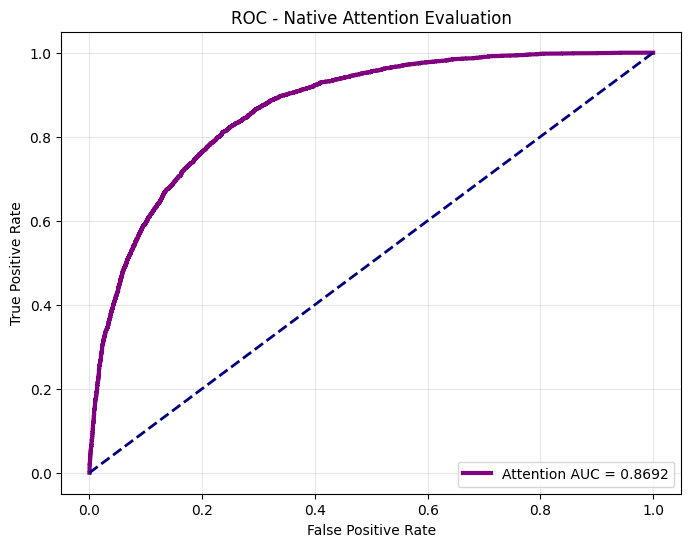

In [10]:
#TEST EWALUAJCI Z WYKORZYSTANIEM ATTENTION MODELU
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, matthews_corrcoef, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# KONFIGURACJA
# ==========================================
# Ustaw bezpieczny limit wycinków na raz, żeby nie wywalić OOM (Out Of Memory).
# Jeśli pacjent ma więcej wycinków, weźmiemy te "środkowe" lub losowe, 
# albo (jeśli masz np. RTX 3090/4090) możesz dać tu nawet 500-1000.
MAX_CROPS_PER_PATIENT = 256 

def evaluate_native_attention(model, loader, device, max_crops=256):
    """
    Ewaluacja wykorzystująca wbudowany mechanizm Attention modelu.
    Nie spłaszcza danych! Traktuje pacjenta jako jeden "Bag".
    """
    model.eval()
    
    y_true_list = []
    y_prob_list = []
    eids_list = []
    
    print(f"🚀 Rozpoczynam ewaluację 'Native Attention' (Max crops: {max_crops})...")
    
    with torch.no_grad():
        # Iterujemy po loaderze (Batch Size = 1 Pacjent)
        for i, data in enumerate(tqdm(loader)):
            
            # 1. Rozpakowanie danych
            if len(data) == 4:
                X, y, eid, timestamps = data
            else:
                X, y, eid = data
                timestamps = None
            
            # X ma kształt: [1, Total_Crops, Channels, Time]
            # y ma kształt: [1] (lub [1, 1])
            
            # --- 2. Zabezpieczenie Pamięci (Subsampling) ---
            num_crops = X.shape[1]
            if num_crops > max_crops:
                # Jeśli pacjent jest za duży na GPU, wybieramy podzbiór
                # (Najlepiej losowy lub równomiernie rozłożony)
                indices = torch.linspace(0, num_crops - 1, max_crops).long()
                X = X[:, indices]
                if timestamps is not None:
                    timestamps = timestamps[:, indices]
            
            X = X.to(dtype=torch.float32, device=device)
            
            # Obsługa Timestamps
            if timestamps is not None:
                timestamps = timestamps.to(device, dtype=torch.long)
            else:
                # Jeśli brak, tworzymy zera [1, Actual_Crops]
                timestamps = torch.zeros((1, X.shape[1]), dtype=torch.long, device=device)

            # --- 3. FORWARD PASS (Bez spłaszczania!) ---
            # Model dostaje [1, Crops, ...]. 
            # Dzięki temu Attention policzy wagi dla wszystkich Crops względem siebie.
            
            try:
                output = model(X, time_stamps=timestamps)
                
                # Jeśli model zwraca krotkę (features, logits), bierzemy logits
                if isinstance(output, tuple):
                    output = output[0] # Logits
                
                # Wynik powinien mieć kształt [1, 1] lub [1, 2]
                if output.shape[0] != 1:
                    # Jeśli model jednak zwrócił [Crops, 1] (znaczy, że nie użył Attention Pooling),
                    # to musimy zrobić mean (fallback).
                    # Ale Twój model MINET powinien zwrócić [1, 1].
                    probs = torch.sigmoid(output).mean().item()
                else:
                    # Klasyczna ścieżka dla MINET z Attention
                    if output.shape[1] == 1:
                        probs = torch.sigmoid(output).item()
                    else:
                        probs = torch.softmax(output, dim=1)[:, 1].item()
                
                y_scalar = y.item() if isinstance(y, torch.Tensor) else y
                
                y_true_list.append(y_scalar)
                y_prob_list.append(probs)
                eids_list.append(eid[0]) # eid to krotka/lista
                
            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"⚠️ OOM dla pacjenta {eid}. Pomijam (lub zmniejsz MAX_CROPS).")
                    torch.cuda.empty_cache()
                else:
                    print(f"❌ Błąd dla pacjenta {eid}: {e}")

    return np.array(y_true_list), np.array(y_prob_list)

# ==========================================
# URUCHOMIENIE
# ==========================================

# Upewnij się, że używasz test_loader_full (tam gdzie batch_size=1)
y_true_att, y_prob_att = evaluate_native_attention(
    model,      # Tutaj podaj original_model (MINET)
    test_loader_full, 
    device, 
    max_crops=300 # Dostosuj do pamięci GPU. 300 to bezpieczny start.
)

# ==========================================
# WYNIKI
# ==========================================
print("\n" + "="*50)
print("WYNIKI: MODEL Z PEŁNYM ATTENTION (Bez groupby)")
print("="*50)

if len(np.unique(y_true_att)) > 1:
    # 1. AUC
    auc_att = roc_auc_score(y_true_att, y_prob_att)
    print(f"🏆 AUC ROC: {auc_att:.4f}")

    # 2. MCC
    fpr, tpr, thresholds = roc_curve(y_true_att, y_prob_att)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    y_pred_bin = (y_prob_att >= best_thresh).astype(int)
    
    mcc_att = matthews_corrcoef(y_true_att, y_pred_bin)
    acc_att = accuracy_score(y_true_att, y_pred_bin)
    
    print(f"✅ MCC:     {mcc_att:.4f} (Próg: {best_thresh:.3f})")
    print(f"   Acc:     {acc_att:.4f}")

    # Wykres
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='purple', lw=3, label=f'Attention AUC = {auc_att:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC - Native Attention Evaluation')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

else:
    print("⚠️ Brak obu klas w zbiorze testowym.")

In [21]:
from sklearn.metrics import calinski_harabasz_score

print("\n" + "="*60)
print("DODATKOWE METRYKI (Calinski-Harabasz)")
print("="*60)

# 1. Dla SZPITALI (Domen)
# CH Index: Stosunek dyspersji międzygrupowej do wewnątrzgrupowej.
# WYSOKI wynik = Silna separacja (Klastry są daleko od siebie i zwarte).
# NISKI wynik = Słaba separacja (Klastry nachodzą na siebie).
try:
    ch_hosp = calinski_harabasz_score(X_viz, H_viz)
    print(f"SZPITALE (Domeny) - Calinski-Harabasz: {ch_hosp:.4f}")
    print("   -> Dla RAW (Baseline): Oczekujemy WYSOKIEGO wyniku (separacja).")
    print("   -> Dla DANN (Cel):     Oczekujemy NISKIEGO wyniku (wymieszanie).")
except Exception as e:
    print(f"Błąd liczenia CH dla szpitali: {e}")

print("-" * 40)

# 2. Dla DIAGNOZY (Klasy)
try:
    ch_diag = calinski_harabasz_score(X_viz, Y_viz)
    print(f"DIAGNOZA (Klasy)  - Calinski-Harabasz: {ch_diag:.4f}")
    print("   -> Cel Medyczny: Im WYŻSZY wynik, tym lepiej (chorzy są oddzieleni od zdrowych).")
except Exception as e:
    print(f"Błąd liczenia CH dla diagnozy: {e}")


print("="*60)
print("ANALIZA JAKOŚCI DIAGNOZY (Norma vs Patologia)")
print("="*60)

# Upewniamy się, że mamy dane
if 'X_viz' in locals() and 'Y_viz' in locals():
    
    # 1. Davies-Bouldin Index (DBI)
    # Wzór: średnie podobieństwo każdego klastra do najbardziej podobnego.
    # Cel: Im MNIEJSZA wartość, tym lepiej (lepsza separacja klas).
    try:
        db_diag = davies_bouldin_score(X_viz, Y_viz)
        print(f"📉 Davies-Bouldin Index: {db_diag:.4f}")
        
        # Interpretacja
        if db_diag < 1.5:
            print("   ✅ WYNIK DOBRY: Klasy są dobrze odseparowane.")
        elif db_diag < 3.0:
            print("   ⚠️ WYNIK PRZECIĘTNY: Klasy trochę na siebie zachodzą.")
        else:
            print("   ❌ WYNIK ZŁY: Klasy są mocno wymieszane (słaba diagnoza).")
            
    except Exception as e:
        print(f"Błąd liczenia DBI: {e}")

    print("-" * 30)

    # 2. Silhouette Score (Opcjonalnie, dla potwierdzenia)
    # Cel: Im WIĘKSZA wartość (blisko 1), tym lepiej.
    try:
        # Liczymy na mniejszej próbce dla szybkości, jeśli danych jest dużo
        limit = 5000
        sil_diag = silhouette_score(X_viz[:limit], Y_viz[:limit], metric='cosine')
        print(f"📈 Silhouette Score:      {sil_diag:.4f}")
        
        if sil_diag > 0.1:
            print("   ✅ Pozytywny (istnieje struktura klastrów).")
        else:
            print("   ⚠️ Bliski zera (klastry się nakładają).")
            
    except Exception as e:
        print(f"Błąd liczenia Silhouette: {e}")

else:
    print("❌ BŁĄD: Nie znaleziono zmiennych X_viz (cechy) i Y_viz (klasy).")
    print("   Uruchom najpierw komórkę zbierającą dane (collect_features...).")


DODATKOWE METRYKI (Calinski-Harabasz)
SZPITALE (Domeny) - Calinski-Harabasz: 22.4177
   -> Dla RAW (Baseline): Oczekujemy WYSOKIEGO wyniku (separacja).
   -> Dla DANN (Cel):     Oczekujemy NISKIEGO wyniku (wymieszanie).
----------------------------------------
DIAGNOZA (Klasy)  - Calinski-Harabasz: 1875.8439
   -> Cel Medyczny: Im WYŻSZY wynik, tym lepiej (chorzy są oddzieleni od zdrowych).
ANALIZA JAKOŚCI DIAGNOZY (Norma vs Patologia)
📉 Davies-Bouldin Index: 1.2171
   ✅ WYNIK DOBRY: Klasy są dobrze odseparowane.
------------------------------
📈 Silhouette Score:      0.3613
   ✅ Pozytywny (istnieje struktura klastrów).


In [22]:
#metryki per pacjent

import pandas as pd
import numpy as np
from sklearn.metrics import davies_bouldin_score, silhouette_score, calinski_harabasz_score

print("--- OBLICZANIE METRYK KLASTROWANIA NA POZIOMIE PACJENTA ---")

# 1. Tworzymy DataFrame dla łatwego grupowania
# Zakładam, że masz zmienne X_all, Y_all, H_all, E_all z poprzedniego kroku
# Jeśli X_all ma np. 288 kolumn, musimy je zachować
df_features = pd.DataFrame(X_all)
feature_cols = df_features.columns.tolist()

df_data = df_features.copy()
df_data['eid'] = E_all
df_data['y_true'] = Y_all
df_data['hospital'] = H_all

# 2. Agregacja (Grupowanie po ID pacjenta)
# Dla cech (X) bierzemy średnią.
# Dla etykiet (Y, H) bierzemy pierwszą wartość (bo pacjent ma jedną chorobę i jeden szpital).
agg_dict = {col: 'mean' for col in feature_cols}
agg_dict['y_true'] = 'first'
agg_dict['hospital'] = 'first'

print(f"Agregacja {len(df_data)} wycinków do poziomu pacjentów...")
df_patient = df_data.groupby('eid').agg(agg_dict).reset_index()

# Wyciągamy z powrotem tablice numpy
X_patient = df_patient[feature_cols].values
Y_patient = df_patient['y_true'].values
H_patient = df_patient['hospital'].values

print(f"Liczba unikalnych pacjentów: {len(X_patient)}")

# 3. OBLICZANIE METRYK (PER PACJENT)
print("\n" + "="*60)
print("WYNIKI 'PER PACJENT' (Średnia cech)")
print("="*60)

# --- A. DIAGNOZA (Chory vs Zdrowy) ---
try:
    db_diag = davies_bouldin_score(X_patient, Y_patient)
    sil_diag = silhouette_score(X_patient, Y_patient, metric='cosine')
    ch_diag = calinski_harabasz_score(X_patient, Y_patient)
    
    print(f"DIAGNOZA (Klasy):")
    print(f"  • Davies-Bouldin:    {db_diag:.4f} (Cel: NISKI)")
    print(f"  • Silhouette:        {sil_diag:.4f} (Cel: WYSOKI)")
    print(f"  • Calinski-Harabasz: {ch_diag:.4f}")
except Exception as e:
    print(f"Błąd diagnozy: {e}")

print("-" * 30)

# --- B. SZPITALE (Domeny) ---
try:
    # Filtrujemy nieznane (-1) jeśli są
    mask = H_patient != -1
    if mask.sum() > 0:
        db_hosp = davies_bouldin_score(X_patient[mask], H_patient[mask])
        ch_hosp = calinski_harabasz_score(X_patient[mask], H_patient[mask])
        # Silhouette na pełnym zbiorze pacjentów (zazwyczaj < 15k) jest szybki
        sil_hosp = silhouette_score(X_patient[mask], H_patient[mask], metric='cosine')
        
        print(f"SZPITALE (Domeny):")
        print(f"  • Davies-Bouldin:    {db_hosp:.4f} (Cel: WYSOKI)")
        print(f"  • Silhouette:        {sil_hosp:.4f} (Cel: NISKI)")
    else:
        print("Brak danych szpitali.")
except Exception as e:
    print(f"Błąd szpitali: {e}")

--- OBLICZANIE METRYK KLASTROWANIA NA POZIOMIE PACJENTA ---
Agregacja 9334 wycinków do poziomu pacjentów...


Liczba unikalnych pacjentów: 9334

WYNIKI 'PER PACJENT' (Średnia cech)
DIAGNOZA (Klasy):
  • Davies-Bouldin:    1.2162 (Cel: NISKI)
  • Silhouette:        0.3664 (Cel: WYSOKI)
  • Calinski-Harabasz: 3596.8202
------------------------------
SZPITALE (Domeny):
  • Davies-Bouldin:    12.6250 (Cel: WYSOKI)
  • Silhouette:        -0.5794 (Cel: NISKI)


📂 Ładowanie mapy szpitali...
✅ Mapa szpitali załadowana. Zmapowano 56898 pacjentów.
🚀 Start ewaluacji 'Original Model' (Max crops: 100)...


9334it [07:12, 21.59it/s]



📊 RAPORT KOŃCOWY: ORIGINAL MODEL (BASELINE)
🩺 MEDYCYNA:
   • AUC ROC: 0.8680
   • MCC:     0.5754 (Próg: 0.62)
------------------------------
📉 DIAGNOZA (Klastrowanie):
   • Davies-Bouldin:   1.2307 (Cel: Niski)
   • Silhouette:       0.2261
   • Calinski-Harab.:  3518.9  (Cel: Wysoki)
📉 DOMENA (Szpitale) (Klastrowanie):
   • Davies-Bouldin:   12.4145 (Cel: Wysoki)
   • Silhouette:       -0.3047
   • Calinski-Harab.:  40.0  (Cel: Niski)
------------------------------
🕵️‍♂️ DOMAIN PROBE (Symulacja MCC dla domeny)...
   ⚠️ Nie udało się policzyć MCC Probe: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
------------------------------
🎨 Generowanie t-SNE...


NameError: name 'mcc_dom_probe' is not defined

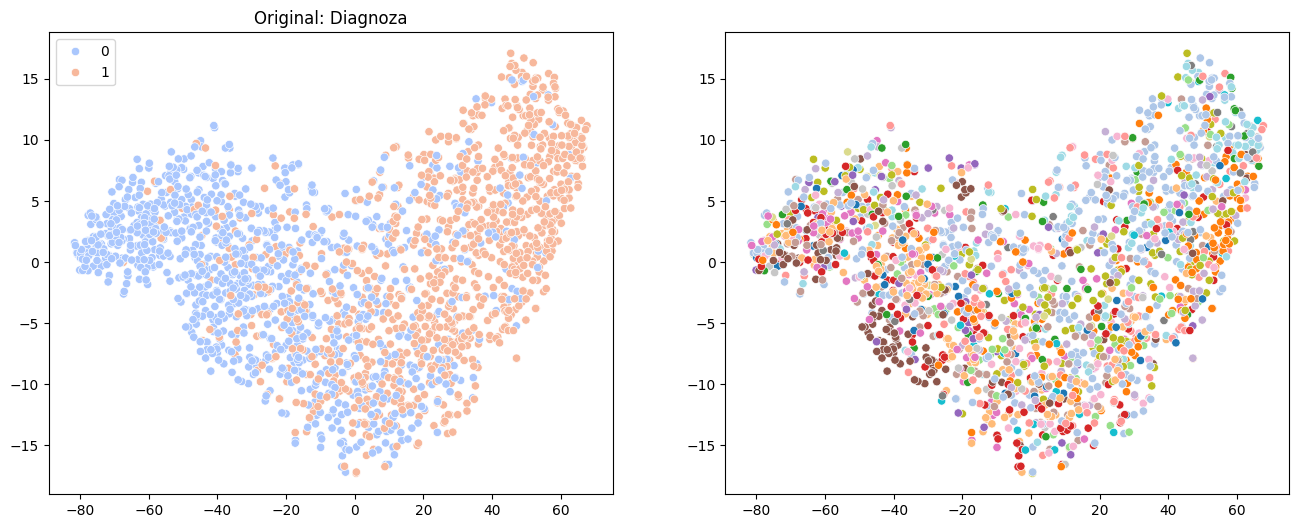

In [3]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, matthews_corrcoef, roc_curve, accuracy_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

# Ignorowanie ostrzeżeń z LogisticRegression (jeśli nie zbiegnie)
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I MAPOWANIE
# ==========================================
csv_path = 'used_label_database.csv'
MAX_CROPS_PER_PATIENT = 100 # Bezpieczniejszy limit dla Original Model

print("📂 Ładowanie mapy szpitali...")
try:
    df_meta = pd.read_csv(csv_path, sep='|', low_memory=False)
    df_meta['examination_id'] = df_meta['examination_id'].astype(str).str.strip()
    df_meta['institution_id'] = df_meta['institution_id'].astype(str).str.strip()
    eid_to_hospital = pd.Series(df_meta.institution_id.values, index=df_meta.examination_id).to_dict()
    print(f"✅ Mapa szpitali załadowana. Zmapowano {len(eid_to_hospital)} pacjentów.")
except Exception as e:
    print(f"❌ Błąd CSV: {e}. Metryki domenowe będą niedostępne.")
    eid_to_hospital = {}

def clean_eid(eid_raw):
    if isinstance(eid_raw, (list, tuple)): eid_raw = eid_raw[0]
    return str(eid_raw).strip()

# ==========================================
# 2. FUNKCJA ZBIERAJĄCA DANE (Z HOOKIEM)
# ==========================================
def collect_features_and_metrics(model, loader, device, max_crops=100):
    model.eval()
    
    y_true_list = []
    y_prob_list = []
    features_list = []
    hosp_list = []
    
    # Hook do wyciągania cech
    extracted_feats = {}
    def get_features_hook(name):
        def hook(model, input, output):
            extracted_feats[name] = input[0].detach().cpu()
        return hook

    # Automatyczne szukanie warstwy klasyfikatora
    handle = None
    target_layer = None
    if hasattr(model, 'classifier'): target_layer = model.classifier
    elif hasattr(model, 'fc'): target_layer = model.fc
    elif hasattr(model, 'module') and hasattr(model.module, 'classifier'): target_layer = model.module.classifier
    
    if target_layer:
        handle = target_layer.register_forward_hook(get_features_hook('feat'))
    else:
        print("⚠️ Nie znaleziono warstwy classifier. Cechy mogą nie zostać pobrane.")

    print(f"🚀 Start ewaluacji 'Original Model' (Max crops: {max_crops})...")
    
    with torch.no_grad():
        for i, data in enumerate(tqdm(loader)):
            if len(data) == 4: X, y, eid, ts = data
            else: X, y, eid = data; ts = None
            
            if X.shape[1] > max_crops:
                indices = torch.linspace(0, X.shape[1]-1, max_crops).long()
                X = X[:, indices]
                if ts is not None: ts = ts[:, indices]
            
            X = X.to(dtype=torch.float32, device=device)
            if ts is not None: ts = ts.to(device, dtype=torch.long)
            else: ts = torch.zeros((1, X.shape[1]), dtype=torch.long, device=device)

            try:
                # Forward
                output = model(X, time_stamps=ts)
                
                # Logits -> Probs
                logits = output[0] if isinstance(output, tuple) else output
                if logits.shape[1] == 1: probs = torch.sigmoid(logits).item()
                else: probs = torch.softmax(logits, dim=1)[:, 1].item()
                
                # Cechy
                if 'feat' in extracted_feats:
                    feat_vec = extracted_feats['feat'].numpy().flatten()
                    features_list.append(feat_vec)
                
                # Metadane
                e_clean = clean_eid(eid)
                h_name = eid_to_hospital.get(e_clean, "Unknown")
                hosp_list.append(h_name)
                
                y_scalar = y.item() if isinstance(y, torch.Tensor) else y
                y_true_list.append(y_scalar)
                y_prob_list.append(probs)
                
            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"⚠️ OOM (Skip): {clean_eid(eid)}")
                    torch.cuda.empty_cache()

    if handle: handle.remove()

    return (np.array(y_true_list), np.array(y_prob_list), 
            np.array(features_list), np.array(hosp_list))

# ==========================================
# 3. URUCHOMIENIE
# ==========================================

# Wstaw swój oryginalny model i loader (test_loader_full)
y_true, y_prob, features, y_dom = collect_features_and_metrics(
    model,             # <--- Twój 'original_model'
    test_loader_full,  # <--- Loader z batch_size=1 (target/test)
    device, 
    max_crops=100
)

# ==========================================
# 4. ROZSZERZONY RAPORT
# ==========================================
print("\n" + "="*60)
print("📊 RAPORT KOŃCOWY: ORIGINAL MODEL (BASELINE)")
print("="*60)

# --- A. DIAGNOZA ---
if len(np.unique(y_true)) > 1:
    auc_val = roc_auc_score(y_true, y_prob)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= best_thresh).astype(int)
    mcc_val = matthews_corrcoef(y_true, y_pred)
    
    print(f"🩺 MEDYCYNA:")
    print(f"   • AUC ROC: {auc_val:.4f}")
    print(f"   • MCC:     {mcc_val:.4f} (Próg: {best_thresh:.2f})")
else:
    print("⚠️ Brak obu klas diagnozy.")

print("-" * 30)

# --- B. KLASTROWANIE (DBI, SIL, CH) ---
def advanced_clustering_metrics(X, labels, name, dbi_goal, ch_goal):
    if len(X) == 0: return
    unique = np.unique(labels)
    if len(unique) < 2:
        print(f"   • {name}: Za mało klas ({len(unique)}) do metryk.")
        return

    # Metryki
    dbi = davies_bouldin_score(X, labels) # Im mniej tym lepiej separowane
    sil = silhouette_score(X, labels)     # Im więcej tym lepiej separowane
    ch = calinski_harabasz_score(X, labels) # Im WIĘCEJ tym lepiej separowane

    print(f"📉 {name} (Klastrowanie):")
    print(f"   • Davies-Bouldin:   {dbi:.4f} ({dbi_goal})")
    print(f"   • Silhouette:       {sil:.4f}")
    print(f"   • Calinski-Harab.:  {ch:.1f}  ({ch_goal})")

if len(features) > 0:
    # 1. Diagnoza (Chcemy separacji: DBI małe, CH duże)
    advanced_clustering_metrics(features, y_true, "DIAGNOZA", 
                                dbi_goal="Cel: Niski", ch_goal="Cel: Wysoki")
    
    # 2. Domena (Chcemy wymieszania: DBI duże, CH małe)
    # W Original Model spodziewamy się, że CH będzie wyższe niż w DANN (bo widzi szpitale)
    # CHYBA ŻE model jest naturalnie odporny, wtedy CH będzie małe.
    advanced_clustering_metrics(features, y_dom, "DOMENA (Szpitale)", 
                                dbi_goal="Cel: Wysoki", ch_goal="Cel: Niski")

print("-" * 30)

# --- C. MCC DOMENY (Domain Probe) ---
# Ponieważ original_model nie ma wyjścia domenowego, trenujemy małą sondę,
# żeby sprawdzić czy cechy zawierają informację o szpitalu.

if len(features) > 0 and len(np.unique(y_dom)) > 1:
    print("🕵️‍♂️ DOMAIN PROBE (Symulacja MCC dla domeny)...")
    try:
        # Kodujemy etykiety szpitali na liczby
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        y_dom_enc = le.fit_transform(y_dom)
        
        # Dzielimy na Train/Test (szybka walidacja)
        # Używamy cech wyciągniętych z modelu jako wejścia
        X_train, X_test, y_d_train, y_d_test = train_test_split(
            features, y_dom_enc, test_size=0.3, stratify=y_dom_enc, random_state=42
        )
        
        # Prosty klasyfikator liniowy (Probe)
        probe = LogisticRegression(max_iter=200, class_weight='balanced')
        probe.fit(X_train, y_d_train)
        
        # Predykcja
        y_d_pred = probe.predict(X_test)
        
        # MCC
        mcc_dom_probe = matthews_corrcoef(y_d_test, y_d_pred)
        acc_dom_probe = accuracy_score(y_d_test, y_d_pred)
        
        print(f"   • MCC Domeny (Probe): {mcc_dom_probe:.4f}")
        print(f"   • Acc Domeny (Probe): {acc_dom_probe:.4f}")
        
        if mcc_dom_probe < 0.2:
            print("   ✅ WNIOSEK: Cechy są anonimowe (Probe nie odróżnia szpitali).")
        else:
            print("   ⚠️ WNIOSEK: Cechy zdradzają szpital (Probe łatwo go zgaduje).")
            
    except Exception as e:
        print(f"   ⚠️ Nie udało się policzyć MCC Probe: {e}")
else:
    print("⚠️ Za mało danych/szpitali do Domain Probe.")

print("-" * 30)

# --- D. WIZUALIZACJA ---
if len(features) > 0:
    print("🎨 Generowanie t-SNE...")
    idx = np.random.choice(len(features), min(2000, len(features)), replace=False)
    X_v, y_v, d_v = features[idx], y_true[idx], y_dom[idx]

    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_emb = tsne.fit_transform(X_v)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y_v, palette='coolwarm', ax=ax[0])
    ax[0].set_title("Original: Diagnoza")
    
    n_doms = len(np.unique(d_v))
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=d_v, palette='tab20', legend=(n_doms<20), ax=ax[1])
    ax[1].set_title(f"Original: Szpitale (MCC Probe: {mcc_dom_probe:.2f})")
    
    plt.tight_layout()
    plt.show()